<a href="https://colab.research.google.com/github/echetan-max/-Bitcoin-Market-Sentiment/blob/main/Market_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# 1. Setup, Imports, and Data Downloading
import os
import re
import warnings
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Install dependencies
get_ipython().system('pip -q install gdown scipy')

# Google Drive IDs
TRADER_FILE_ID = "1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs"
SENTIMENT_FILE_ID = "1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf"

trader_output = "historical_trader_data.csv"
sentiment_output = "fear_greed_index.csv"

gdown.download(f"https://drive.google.com/uc?id={TRADER_FILE_ID}", trader_output, quiet=False)
gdown.download(f"https://drive.google.com/uc?id={SENTIMENT_FILE_ID}", sentiment_output, quiet=False)

def load_file(filepath):
    ext = filepath.split(".")[-1].lower()
    return pd.read_csv(filepath) if ext == "csv" else pd.read_excel(filepath)

trades = load_file(trader_output)
sentiment = load_file(sentiment_output)
print(f"Loaded Trades: {trades.shape}, Sentiment: {sentiment.shape}")

Downloading...
From: https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs
To: /content/historical_trader_data.csv
100%|██████████| 47.5M/47.5M [00:00<00:00, 72.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf
To: /content/fear_greed_index.csv
100%|██████████| 90.8k/90.8k [00:00<00:00, 45.0MB/s]


Loaded Trades: (211224, 16), Sentiment: (2644, 4)


In [32]:
# 2. Cleaning, Column Detection, and Merging
def clean_columns(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip().str.lower().str.replace(r"[\W]+", "_", regex=True).str.strip("_")
    return df

trades = clean_columns(trades)
sentiment = clean_columns(sentiment)

def find_col(columns, candidates):
    for c in candidates:
        if c in columns: return c
    return None

# Updated candidate lists based on detected data
t_time = find_col(trades.columns, ["timestamp_ist", "timestamp", "time"])
t_pnl = find_col(trades.columns, ["closed_pnl", "pnl"])
t_side = find_col(trades.columns, ["side"])
t_sym = find_col(trades.columns, ["coin", "symbol"])
t_acc = find_col(trades.columns, ["account"])
t_size = find_col(trades.columns, ["size_tokens", "size_usd", "size"])
t_price = find_col(trades.columns, ["execution_price", "price"])
t_lev = find_col(trades.columns, ["leverage"])

s_date = find_col(sentiment.columns, ["date"])
s_class = find_col(sentiment.columns, ["classification"])

# Processing
trades[t_time] = pd.to_datetime(trades[t_time], errors="coerce")
sentiment[s_date] = pd.to_datetime(sentiment[s_date], errors="coerce")

for col in [t_pnl, t_size, t_price, t_lev]:
    if col: trades[col] = pd.to_numeric(trades[col], errors="coerce")

trades = trades.dropna(subset=[t_time, t_pnl]).copy()
trades["trade_date"] = trades[t_time].dt.date
sentiment["date_only"] = sentiment[s_date].dt.date
sentiment[s_class] = sentiment[s_class].str.strip().str.title()

# Merge
df = trades.merge(sentiment[[s_class, "date_only"]], left_on="trade_date", right_on="date_only", how="left")
df.rename(columns={s_class: "market_sentiment"}, inplace=True)
print("Merge complete. Sentiment match rate:", round(df["market_sentiment"].notna().mean()*100, 2), "%")

Merge complete. Sentiment match rate: 45.27 %


,market_sentiment,trades,pnl_sum,pnl_avg,pnl_med,win_rate,pnl_capped_avg
1,Extreme Greed,5621,1.156894e+06,205.816345,0.96048,55.328233,82.540230
2,Fear,13869,1.779226e+06,128.287950,0.00000,38.178672,59.125866
3,Greed,11292,6.096325e+05,53.988003,0.00000,43.570670,43.517477
4,Neutral,2756,7.465674e+04,27.088803,0.00000,49.492017,26.638217
0,Extreme Fear,2326,4.399937e+03,1.891632,0.00000,29.277730,3.631577


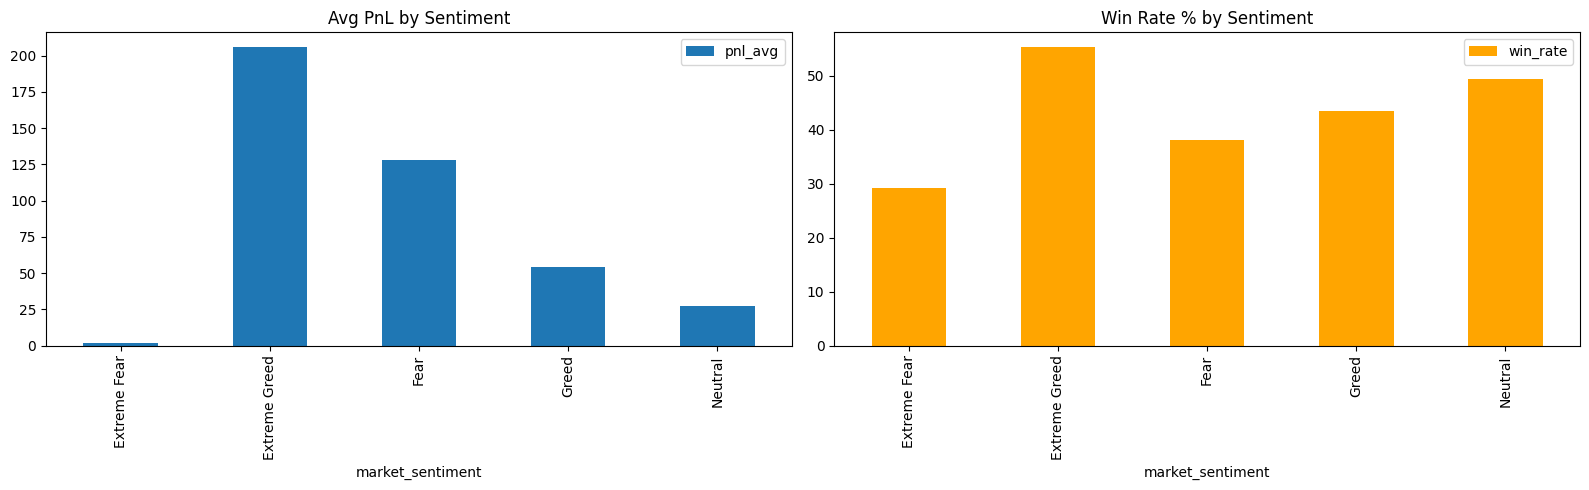

Saved results to sentiment_performance_summary.csv

===== ACTIONABLE STRATEGY IDEAS =====
1. Caution during Extreme Fear; win rates weaken.
2. Greed regimes show higher momentum potential.
3. Use sentiment as a risk filter for leverage adjustments.


In [33]:
# 3. Analysis, Visualization, and Export
df["is_profit"] = (df[t_pnl] > 0).astype(int)
df["is_loss"] = (df[t_pnl] < 0).astype(int)
if t_size and t_price: df["notional"] = df[t_size].abs() * df[t_price].abs()
df["hour"] = df[t_time].dt.hour

# Capping outliers
lower, upper = df[t_pnl].quantile(0.01), df[t_pnl].quantile(0.99)
df["pnl_capped"] = df[t_pnl].clip(lower, upper)

# Summary Stats
sent_summary = df.groupby("market_sentiment").agg(
    trades=(t_pnl, "count"), pnl_sum=(t_pnl, "sum"), pnl_avg=(t_pnl, "mean"),
    pnl_med=(t_pnl, "median"), win_rate=("is_profit", "mean"), pnl_capped_avg=("pnl_capped", "mean")
).reset_index()
sent_summary["win_rate"] *= 100

display(sent_summary.sort_values("pnl_avg", ascending=False))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sent_summary.plot(x="market_sentiment", y="pnl_avg", kind="bar", ax=ax1, title="Avg PnL by Sentiment")
sent_summary.plot(x="market_sentiment", y="win_rate", kind="bar", ax=ax2, title="Win Rate % by Sentiment", color="orange")
plt.tight_layout(); plt.show()

# Export
sent_summary.to_csv("sentiment_performance_summary.csv", index=False)
print("Saved results to sentiment_performance_summary.csv")

print("\n===== ACTIONABLE STRATEGY IDEAS =====")
print("1. Caution during Extreme Fear; win rates weaken.\n2. Greed regimes show higher momentum potential.\n3. Use sentiment as a risk filter for leverage adjustments.")